# $(SASA) Baseline$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Base_Line_Model
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
1398,13,57,"(0.4858968354133477, 0.4002511587990111)","(0.084, -0.192, -0.143, 0.148)",0,1.0,"(0.08, -0.393, -0.14, 0.57)",0.0,1.0,"(0.072, -0.594, -0.129, 0.994)"
1938,19,77,"(0.1064004661572971, 0.3173964772630564)","(-0.001, -0.571, -0.062, 0.652)",1,1.0,"(-0.012, -0.367, -0.049, 0.159)",1.0,1.0,"(-0.02, -0.163, -0.046, -0.328)"
1655,43,66,"(0.0609425168772551, 1.2010637267216533)","(0.075, 1.693, 0.016, -0.805)",0,1.0,"(0.109, 1.506, -0.0, -0.685)",1.0,1.0,"(0.139, 1.693, -0.014, -0.803)"
1693,15,67,"(0.0550547819736606, 0.7277451834527079)","(-0.092, -0.23, 0.069, 0.214)",1,1.0,"(-0.097, -0.04, 0.073, 0.034)",0.0,1.0,"(-0.098, -0.231, 0.074, 0.243)"
1116,14,46,"(0.5759890361457483, 0.539204361971833)","(0.065, 0.366, -0.104, -0.976)",0,1.0,"(0.073, 0.168, -0.124, -0.61)",0.0,1.0,"(0.076, -0.03, -0.136, -0.256)"
...,...,...,...,...,...,...,...,...,...,...
1636,24,66,"(0.0609425168772551, 1.2010637267216533)","(-0.165, 0.39, 0.096, -0.147)",1,1.0,"(-0.158, 0.577, 0.093, -0.253)",0.0,1.0,"(-0.146, 0.389, 0.088, -0.123)"
872,4,35,"(0.7510043618705947, 0.8768677218696304)","(-0.04, -0.792, 0.087, 1.384)",0,1.0,"(-0.056, -0.989, 0.115, 1.729)",1.0,1.0,"(-0.076, -0.795, 0.149, 1.455)"
771,16,27,"(0.3197179553472873, 0.8108021737171857)","(0.069, 0.375, -0.129, -0.679)",0,1.0,"(0.076, 0.185, -0.143, -0.497)",0.0,1.0,"(0.08, -0.005, -0.153, -0.318)"
459,11,19,"(0.0642916329828742, 1.239005358213764)","(-0.085, -0.144, 0.019, 0.063)",0,1.0,"(-0.087, -0.331, 0.02, 0.18)",0.0,1.0,"(-0.094, -0.518, 0.023, 0.298)"


In [3]:
model = Base_Line_Model()

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,mse_s,transition,reward
0,0,"[0.2176016867160797, 0.6510571837425232, 0.145...",2.059476,0.753885
1,1,"[0.21306392550468445, 0.6453166007995605, 0.14...",2.039006,0.744386
2,2,"[0.20858745276927948, 0.6396320462226868, 0.13...",2.018738,0.735026
3,3,"[0.20417258143424988, 0.6340035796165466, 0.13...",1.998671,0.725809
4,4,"[0.19981969892978668, 0.6284312009811401, 0.13...",1.978804,0.716734


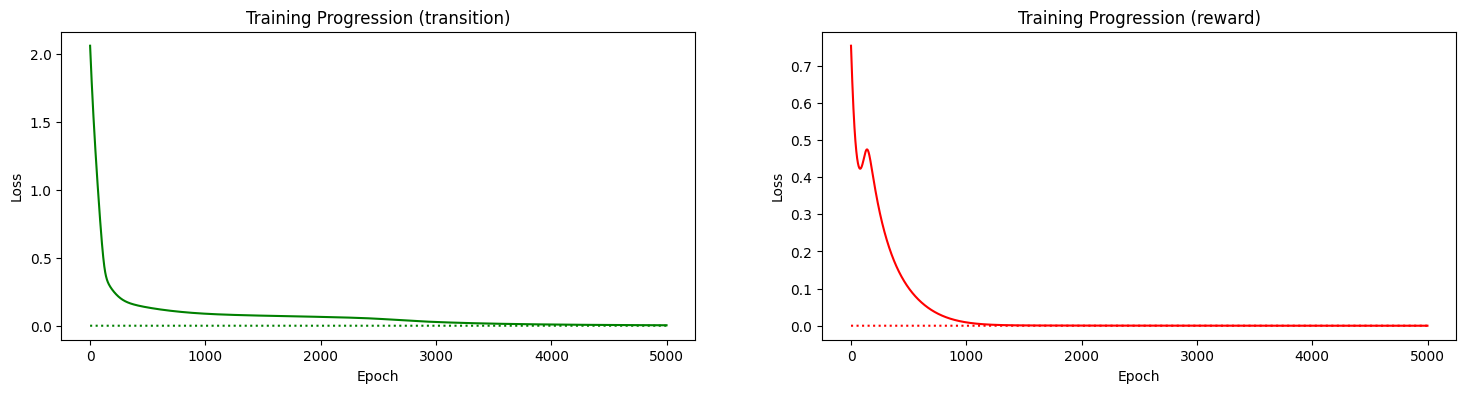

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

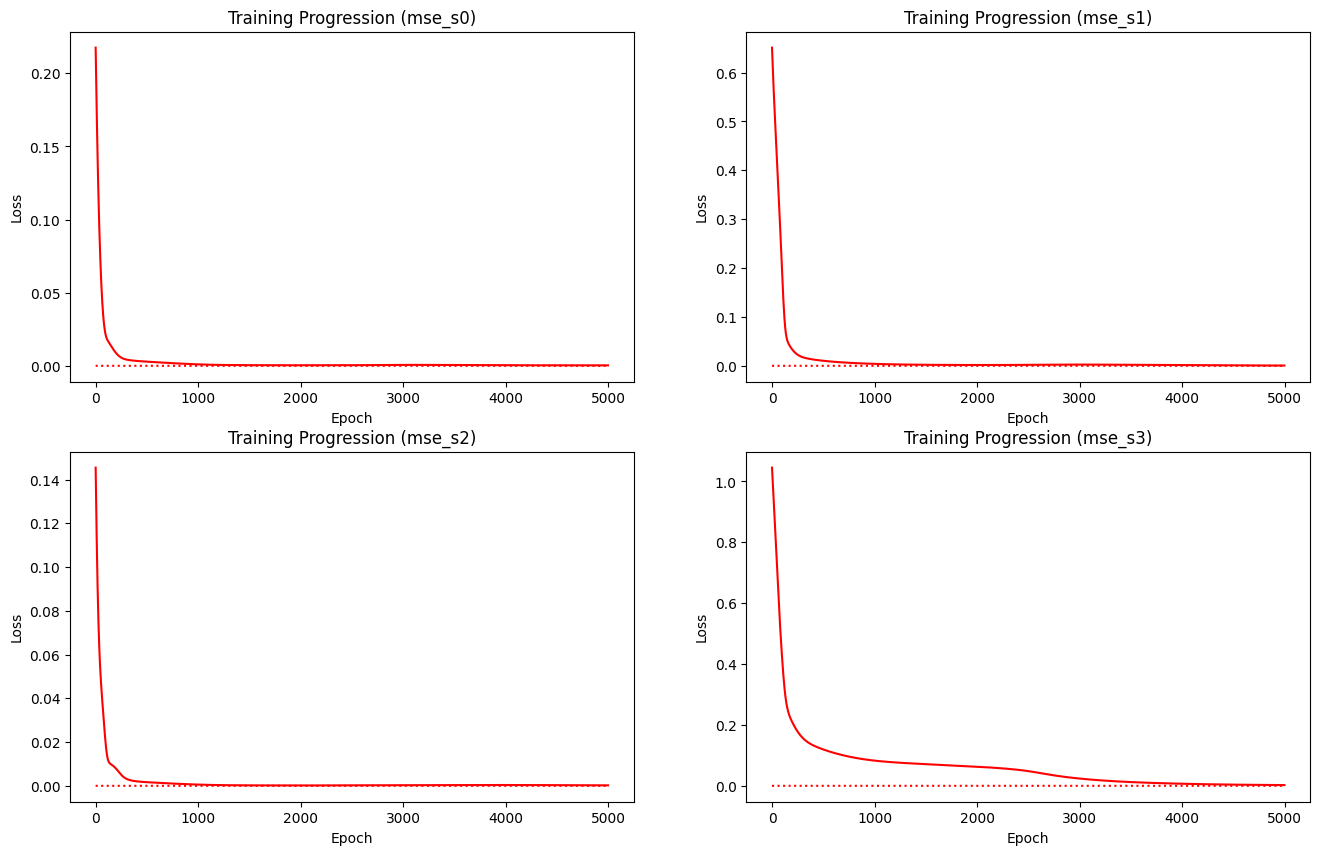

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

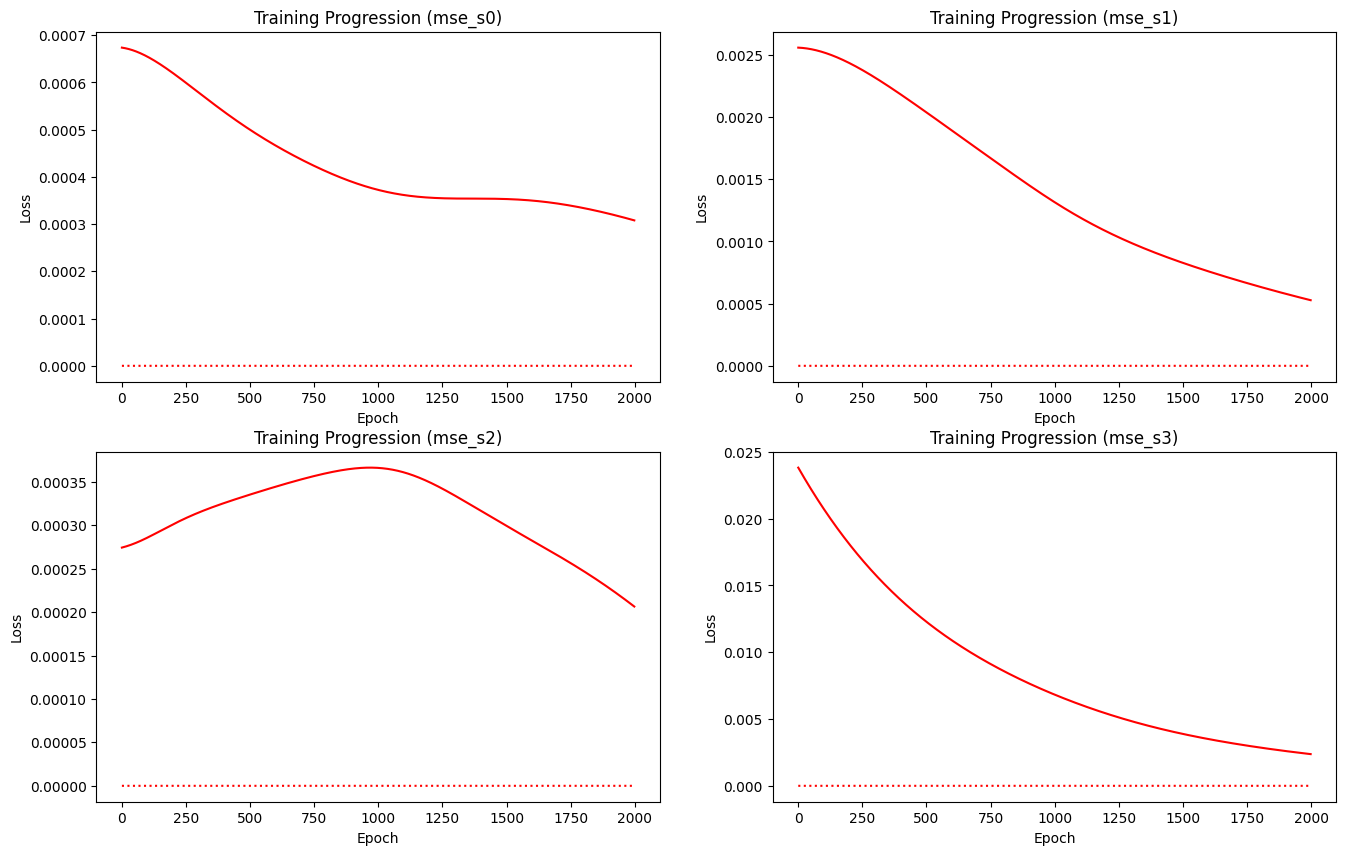

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data[train_data.epoch>3000].reset_index(drop=True), expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

# Evaluation

In [7]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics(p=False)
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
0,0,0,"(0.5280280669895349, 0.1691488904272192)","(-0.018, -0.046, 0.013, -0.019)",0,1.0,"(-0.019, -0.285, 0.013, 1.258)",0.0,1.0,"(-0.025, -0.525, 0.038, 2.534)",...,0.047,0.016,0.193,0.0,0.235294,0.215596,0.156863,0.525886,0.304,0.512069
1,1,0,"(0.5280280669895349, 0.1691488904272192)","(-0.019, -0.285, 0.013, 1.258)",0,1.0,"(-0.025, -0.525, 0.038, 2.534)",1.0,1.0,"(-0.035, -0.288, 0.088, 1.326)",...,0.031,0.031,0.079,0.0,0.215686,0.142202,0.303922,0.215259,0.185,0.306897
2,2,0,"(0.5280280669895349, 0.1691488904272192)","(-0.025, -0.525, 0.038, 2.534)",1,1.0,"(-0.035, -0.288, 0.088, 1.326)",0.0,1.0,"(-0.041, -0.532, 0.115, 2.694)",...,0.097,0.017,0.078,0.0,0.171569,0.444954,0.166667,0.212534,0.227,0.379310
3,3,0,"(0.5280280669895349, 0.1691488904272192)","(-0.035, -0.288, 0.088, 1.326)",0,1.0,"(-0.041, -0.532, 0.115, 2.694)",1.0,1.0,"(-0.052, -0.3, 0.169, 1.601)",...,0.021,0.025,0.071,0.0,0.205882,0.096330,0.245098,0.193460,0.159,0.262069
4,4,0,"(0.5280280669895349, 0.1691488904272192)","(-0.041, -0.532, 0.115, 2.694)",1,1.0,"(-0.052, -0.3, 0.169, 1.601)",0.0,1.0,"(-0.058, -0.546, 0.201, 3.045)",...,0.129,0.021,0.250,0.0,0.205882,0.591743,0.205882,0.681199,0.442,0.750000


In [ ]:
results[['rse_s0','rse_s1','rse_s2','rse_s3','rse_r','rse_s0_normalized','rse_s1_normalized','rse_s2_normalized','rse_s3_normalized', 'rse']].describe()

,rse_s0,rse_s1,rse_s2,rse_s3,rse_r,rse_s0_normalized,rse_s1_normalized,rse_s2_normalized,rse_s3_normalized,rse,rse_normalized
count,2127.000000,2127.000000,2127.000000,2127.000000,2127.0,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000,2127.000000
mean,0.010661,0.012058,0.009427,0.028341,0.0,0.052262,0.055313,0.092425,0.077223,0.060488,0.092221
std,0.014166,0.015080,0.008736,0.037335,0.0,0.069441,0.069172,0.085643,0.101729,0.058830,0.101430
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.007000,0.000000
25%,0.003000,0.004000,0.004000,0.008000,0.0,0.014706,0.018349,0.039216,0.021798,0.029000,0.037931
50%,0.007000,0.008000,0.008000,0.017000,0.0,0.034314,0.036697,0.078431,0.046322,0.044000,0.063793
75%,0.013000,0.015000,0.013000,0.034000,0.0,0.063725,0.068807,0.127451,0.092643,0.068000,0.105172
max,0.204000,0.218000,0.102000,0.367000,0.0,1.000000,1.000000,1.000000,1.000000,0.587000,1.000000


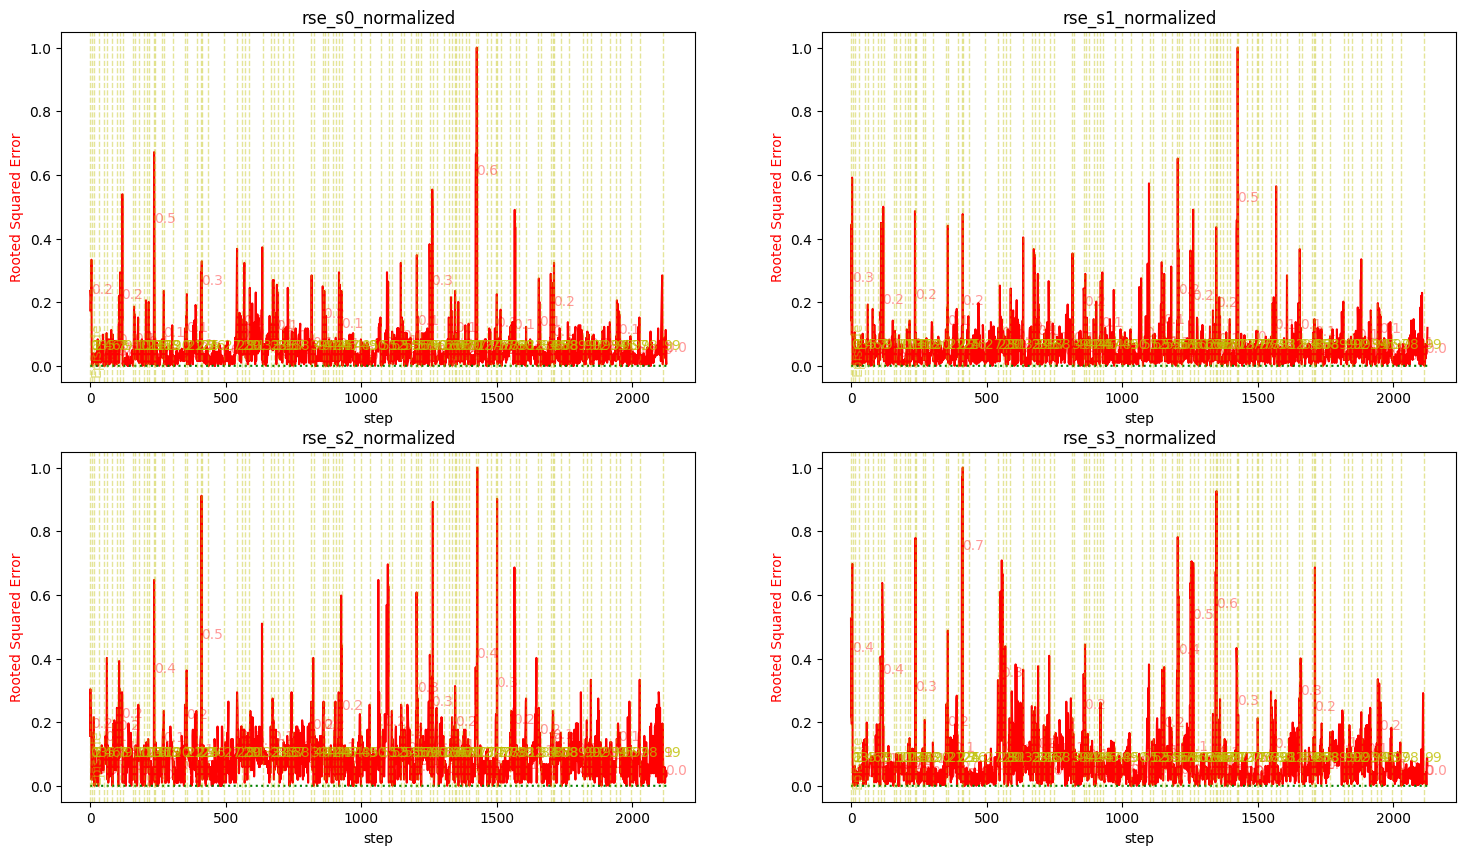

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0_normalized')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1_normalized')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2_normalized')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3_normalized')

plt.show()

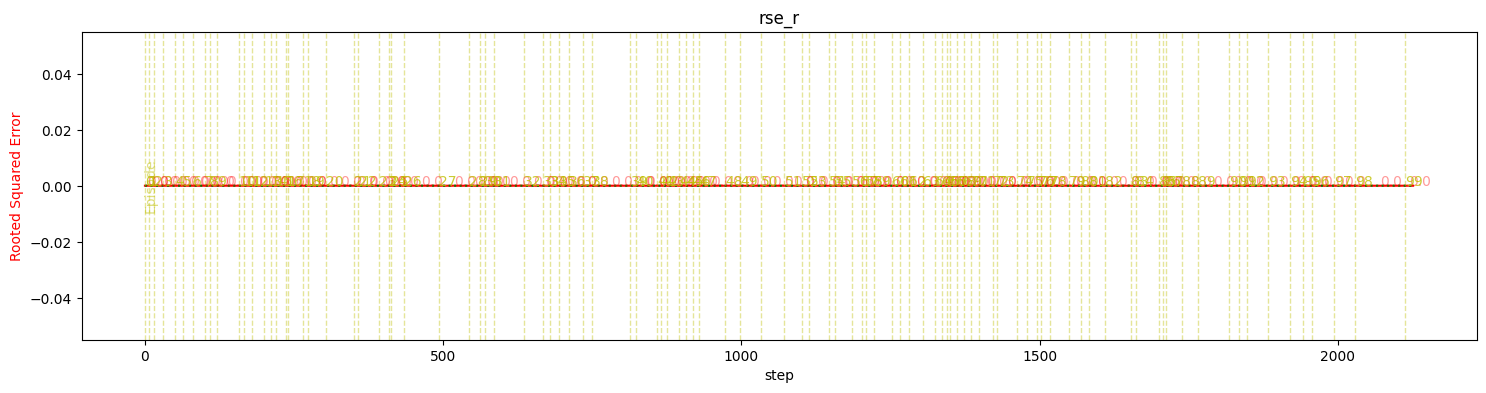

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

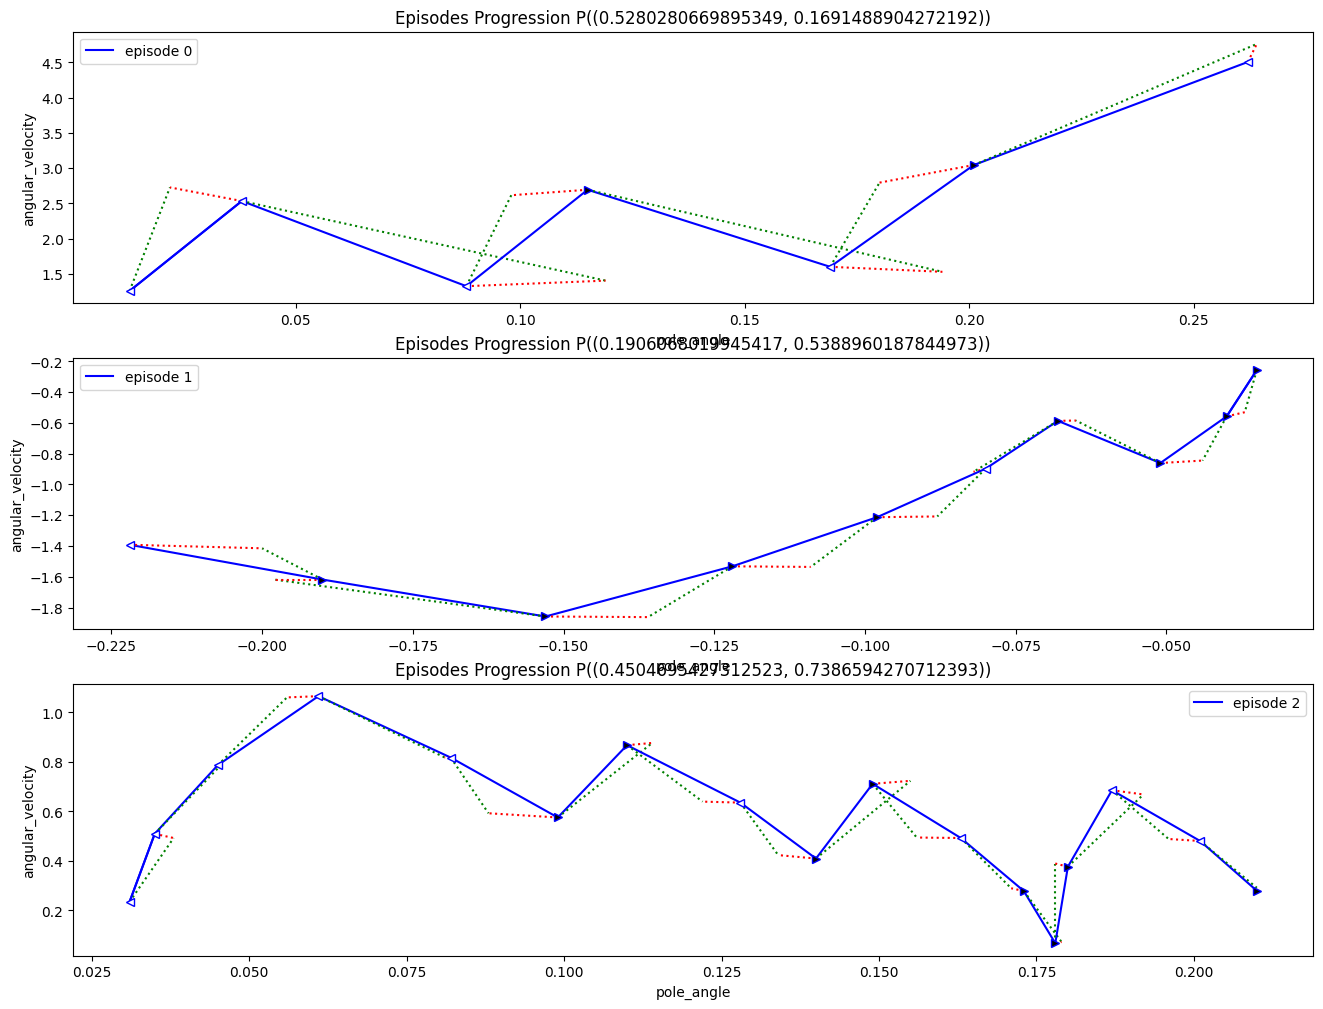

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()